<h1 style="color: red; font-size: 48px; text-align: center;">Predictive Maintenance &mdash; Remaining Useful Life (RUL) Prediction</h1>

<center>
    <img src="https://media.tenor.com/H_Cpn0K0IO0AAAAC/jet-engine.gif" alt="jet engine turbine" height="200" width="500">
</center>

# 👋 Introduction

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The objective of this project is to build a predictive model that estimates the <b>Remaining Useful Life (RUL)</b> of industrial turbofan engines from multivariate sensor measurements.
    Accurate RUL prediction lets maintenance teams act <i>before</i> a failure occurs &mdash; scheduling repairs at the optimal time, avoiding unplanned downtime, and extending asset life.
    Using NASA's <b>C-MAPSS Turbofan Engine Degradation</b> dataset, we aim to learn the complex degradation patterns hidden in 21 sensor channels and three operational settings.
</div>

# 📚 Problem Statement

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Industrial equipment degrades through a combination of mechanical wear, thermal stress, and operating conditions.
    Unplanned failure of a single asset can cost manufacturers up to <b>$260K per hour</b> of downtime, yet most failures are predictable from sensor trends 48&ndash;72 hours in advance.
    By framing prognostics as a supervised regression task &mdash; mapping a window of sensor readings to the number of cycles remaining before failure &mdash;
    we can automate health assessment and drive prediction-based maintenance scheduling.
</div>

# 🔭 Feature Description

<div style="font-family:verdana; font-size: 20px; line-height: 1.7em;">
<ol>
<li><p><strong><code>unit</code></strong>: Engine identifier. Each unit is an independent run-to-failure trajectory of the same engine model.</p></li>

<li><p><strong><code>cycle</code></strong>: The operational time step (flight cycle) for a given engine. Degradation accumulates as the cycle count grows.</p></li>

<li><p><strong><code>op_setting_1</code>, <code>op_setting_2</code>, <code>op_setting_3</code></strong>: Three operational settings (altitude, Mach number, throttle resolver angle) that define the flight regime and strongly affect every sensor reading.</p></li>

<li><p><strong><code>sensor_1</code> &hellip; <code>sensor_21</code></strong>: Twenty-one onboard sensor measurements &mdash; fan and core temperatures, pressures, rotational speeds, fuel flow, and bleed measurements &mdash; that jointly characterise the engine's health state. Several sensors are flat (no signal) and will be removed.</p></li>

<li><p><strong><code>RUL</code></strong>: The <b>target</b> variable &mdash; the number of operational cycles remaining before the engine fails. For training it is derived per engine as <code>(max_cycle - current_cycle)</code> and clipped at 125 cycles (a standard C-MAPSS convention).</p></li>
</ol>

<p>
These features capture the physical state of the engine, the operating regime, and the temporal progression of wear.
Modelling their interactions is the key to an accurate, trustworthy RUL estimate.
</p>
</div>

# 🎯 Project Goals

<div class="alert alert-block alert-warning" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li>Perform exploratory data analysis (EDA) to understand sensor behaviour and degradation trends.</li>
        <li>Engineer and select the sensor features that carry real predictive signal.</li>
        <li>Develop baseline and gradient-boosted regression models and compare them using RMSE and R&sup2; metrics.</li>
        <li>Stack multiple models with a meta-learner to maximise predictive accuracy.</li>
        <li>Produce a final RUL prediction and benchmark it against NASA's ground-truth labels.</li>
    </ul>
</div>

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import glob
import math

from rich.console import Console
from rich.table import Table

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set(font_scale=1.1)

# Load Data

In [2]:
index_names = ['unit', 'cycle']
setting_names = [f'op_setting_{i}' for i in range(1, 4)]
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# Locate the C-MAPSS FD001 files. Works in three ways, in order:
#   1. Dataset attached via 'Add Input'  -> found under /kaggle/input
#   2. Not attached                      -> downloaded with kagglehub (needs Internet ON
#      in the notebook's Session options)
#   3. Running locally                   -> found next to the notebook
search_roots = ['/kaggle/input']

def find_file(name, roots):
    for root in roots:
        matches = glob.glob(f'{root}/**/{name}', recursive=True)
        if matches:
            return matches[0]
    matches = glob.glob(f'**/{name}', recursive=True)  # local fallback
    return matches[0] if matches else None

if find_file('train_FD001.txt', search_roots) is None:
    import kagglehub
    path = kagglehub.dataset_download('behrad3d/nasa-cmaps')
    print(f"Downloaded dataset via kagglehub to: {path}")
    search_roots.append(path)

def load(name, **kwargs):
    f = find_file(name, search_roots)
    if f is None:
        raise FileNotFoundError(
            f"'{name}' not found. Either attach the 'nasa-cmaps' dataset via Add Input, "
            "or enable Internet in Session options so kagglehub can download it."
        )
    print(f"Loading: {f}")
    return pd.read_csv(f, sep=r'\s+', header=None, **kwargs)

train = load('train_FD001.txt', names=col_names)
test = load('test_FD001.txt', names=col_names)
rul_truth = load('RUL_FD001.txt', names=['RUL'])

print(f"\ntrain: {train.shape}, test: {test.shape}, rul_truth: {rul_truth.shape}")

Downloaded dataset via kagglehub to: C:\Users\VICTUS\.cache\kagglehub\datasets\behrad3d\nasa-cmaps\versions\1
Loading: C:\Users\VICTUS\.cache\kagglehub\datasets\behrad3d\nasa-cmaps\versions\1\CMaps\train_FD001.txt
Loading: C:\Users\VICTUS\.cache\kagglehub\datasets\behrad3d\nasa-cmaps\versions\1\CMaps\test_FD001.txt
Loading: C:\Users\VICTUS\.cache\kagglehub\datasets\behrad3d\nasa-cmaps\versions\1\CMaps\RUL_FD001.txt

train: (20631, 26), test: (13096, 26), rul_truth: (100, 1)


In [3]:
# Derive the Remaining Useful Life (RUL) target for the training set:
# for each engine, RUL at a given cycle = (last cycle of that engine) - (current cycle).
# RUL is clipped at 125 cycles, a standard C-MAPSS convention that focuses the model
# on the degradation phase rather than the long, healthy early life of the engine.
RUL_CLIP = 125
max_cycle = train.groupby('unit')['cycle'].transform('max')
train['RUL'] = (max_cycle - train['cycle']).clip(upper=RUL_CLIP)

In [4]:
# The test set provides only a partial run for each engine; the prediction target
# is the RUL at the LAST observed cycle of every engine (matched to RUL_FD001.txt).
test_last = test.groupby('unit').last().reset_index()

In [5]:
train.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


In [6]:
def custom_describe(df, categorical=False):

    if not categorical:
        df = df.select_dtypes(include=np.number)

    des = df.describe().T.round(2)
    des['count'] = des['count'].astype('int')

    if not categorical:
        des['skewness'] = df.skew().round(2)
        des['kurtosis'] = df.kurtosis().round(2)

    return des

In [7]:
def df_summary(df, label="Train"):
    console = Console()
    console.rule(f"[bold blue]{label} DataFrame Description[/bold blue]")

    console.print(f"[bold]Shape:[/bold] {df.shape}\n")

    # Numeric summary
    numeric_cols = df.select_dtypes(include=np.number).columns
    if len(numeric_cols) > 0:
        console.print("[bold blue]Numerical Columns:[/bold blue]")
        num_stats = custom_describe(df[numeric_cols], categorical=False)
        table = Table(show_header=True, header_style="bold magenta")
        table.add_column("Column")
        for col in num_stats.columns:
            table.add_column(col)
        for idx, row in num_stats.iterrows():
            table.add_row(idx, *[f"{val:.2f}" if isinstance(val, (float, np.float64)) else str(val) for val in row])
        console.print(table)
        console.print("\n")

    # Categorical summary
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) > 0:
        console.print("[bold blue]Categorical Columns:[/bold blue]")
        cat_stats = df[cat_cols].describe().T
        table = Table(show_header=True, header_style="bold magenta")
        table.add_column("Column")
        for col in cat_stats.columns:
            table.add_column(col)
        for idx, row in cat_stats.iterrows():
            table.add_row(idx, *[str(val) for val in row])
        console.print(table)
        console.print("\n")

df_summary(train)
df_summary(test, "Test")

─────────────────────────────────────────── Train DataFrame Description ───────────────────────────────────────────

Shape: (20631, 27)

Numerical Columns:

┏━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃ Column     ┃ count    ┃ mean    ┃ std   ┃ min     ┃ 25%     ┃ 50%     ┃ 75%     ┃ max     ┃ skewness ┃ kurtosis ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ unit       │ 20631.00 │ 51.51   │ 29.23 │ 1.00    │ 26.00   │ 52.00   │ 77.00   │ 100.00  │ -0.07    │ -1.22    │
│ cycle      │ 20631.00 │ 108.81  │ 68.88 │ 1.00    │ 52.00   │ 104.00  │ 156.00  │ 362.00  │ 0.50     │ -0.22    │
│ op_settin… │ 20631.00 │ -0.00   │ 0.00  │ -0.01   │ -0.00   │ 0.00    │ 0.00    │ 0.01    │ -0.02    │ -0.01    │
│ op_settin… │ 20631.00 │ 0.00    │ 0.00  │ -0.00   │ -0.00   │ 0.00    │ 0.00    │ 0.00    │ 0.01     │ -1.13    │
│ op_settin… │ 20631.00 │ 100.00  │ 0.00  │ 100.00  │ 100.00  │ 100.00  │ 100.00  │ 100.00  │ 0.00     │ 0.00     │
│ sensor_1   │ 20631.00 │ 518.67  │ 0.00  │ 518.67  │ 518.67  │ 518.67  │ 518.67  │ 518.67  │ 0.00     │ 0.00     │
│ sensor_2   │ 20631.00 │ 642.68  │ 0.50  │ 641.21  │ 642.33  │ 642.64  │ 643.00  │ 644.53  │ 0.32     │ -0.11    │
│ sensor_3   │ 20631.00 │ 1590.52 │ 6.13  │ 1571.04 │ 1586.26 │ 1590.10 │ 1594.38 │ 1616.91 │ 0.31     │ 0.01     │
│ sensor_4   │ 20631.00 │ 1408.93 │ 9.00  │ 1382.25 │ 1402.36 │ 1408.04 │ 1414.55 │ 1441.49 │ 0.44     │ -0.16    │
│ sensor_5   │ 20631.00 │ 14.62   │ 0.00  │ 14.62   │ 14.62   │ 14.62   │ 14.62   │ 14.62   │ -1.00    │ -2.00    │
│ sensor_6   │ 20631.00 │ 21.61   │ 0.00  │ 21.60   │ 21.61   │ 21.61   │ 21.61   │ 21.61   │ -6.92    │ 45.85    │
│ sensor_7   │ 20631.00 │ 553.37  │ 0.89  │ 549.85  │ 552.81  │ 553.44  │ 554.01  │ 556.06  │ -0.39    │ -0.16    │
│ sensor_8   │ 20631.00 │ 2388.10 │ 0.07  │ 2387.90 │ 2388.05 │ 2388.09 │ 2388.14 │ 2388.56 │ 0.48     │ 0.33     │
│ sensor_9   │ 20631.00 │ 9065.24 │ 22.08 │ 9021.73 │ 9053.10 │ 9060.66 │ 9069.42 │ 9244.59 │ 2.56     │ 9.38     │
│ sensor_10  │ 20631.00 │ 1.30    │ 0.00  │ 1.30    │ 1.30    │ 1.30    │ 1.30    │ 1.30    │ 0.00     │ 0.00     │
│ sensor_11  │ 20631.00 │ 47.54   │ 0.27  │ 46.85   │ 47.35   │ 47.51   │ 47.70   │ 48.53   │ 0.47     │ -0.17    │
│ sensor_12  │ 20631.00 │ 521.41  │ 0.74  │ 518.69  │ 520.96  │ 521.48  │ 521.95  │ 523.38  │ -0.44    │ -0.14    │
│ sensor_13  │ 20631.00 │ 2388.10 │ 0.07  │ 2387.88 │ 2388.04 │ 2388.09 │ 2388.14 │ 2388.56 │ 0.47     │ 0.39     │
│ sensor_14  │ 20631.00 │ 8143.75 │ 19.08 │ 8099.94 │ 8133.24 │ 8140.54 │ 8148.31 │ 8293.72 │ 2.37     │ 8.85     │
│ sensor_15  │ 20631.00 │ 8.44    │ 0.04  │ 8.32    │ 8.41    │ 8.44    │ 8.47    │ 8.58    │ 0.39     │ -0.12    │
│ sensor_16  │ 20631.00 │ 0.03    │ 0.00  │ 0.03    │ 0.03    │ 0.03    │ 0.03    │ 0.03    │ 0.00     │ 0.00     │
│ sensor_17  │ 20631.00 │ 393.21  │ 1.55  │ 388.00  │ 392.00  │ 393.00  │ 394.00  │ 400.00  │ 0.35     │ -0.04    │
│ sensor_18  │ 20631.00 │ 2388.00 │ 0.00  │ 2388.00 │ 2388.00 │ 2388.00 │ 2388.00 │ 2388.00 │ 0.00     │ 0.00     │
│ sensor_19  │ 20631.00 │ 100.00  │ 0.00  │ 100.00  │ 100.00  │ 100.00  │ 100.00  │ 100.00  │ 0.00     │ 0.00     │
│ sensor_20  │ 20631.00 │ 38.82   │ 0.18  │ 38.14   │ 38.70   │ 38.83   │ 38.95   │ 39.43   │ -0.36    │ -0.11    │
│ sensor_21  │ 20631.00 │ 23.29   │ 0.11  │ 22.89   │ 23.22   │ 23.30   │ 23.37   │ 23.62   │ -0.35    │ -0.12    │
│ RUL        │ 20631.00 │ 86.83   │ 41.67 │ 0.00    │ 51.00   │ 103.00  │ 125.00  │ 125.00  │ -0.64    │ -1.07    │
└────────────┴──────────┴─────────┴───────┴─────────┴─────────┴─────────┴─────────┴─────────┴──────────┴──────────┘

─────────────────────────────────────────── Test DataFrame Description ────────────────────────────────────────────

Shape: (13096, 26)

Numerical Columns:

┏━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┓
┃ Column     ┃ count    ┃ mean    ┃ std   ┃ min     ┃ 25%     ┃ 50%     ┃ 75%     ┃ max     ┃ skewness ┃ kurtosis ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━┩
│ unit       │ 13096.00 │ 51.54   │ 28.29 │ 1.00    │ 28.00   │ 52.00   │ 76.00   │ 100.00  │ 0.00     │ -1.17    │
│ cycle      │ 13096.00 │ 76.84   │ 53.06 │ 1.00    │ 33.00   │ 69.00   │ 113.00  │ 303.00  │ 0.72     │ 0.21     │
│ op_settin… │ 13096.00 │ -0.00   │ 0.00  │ -0.01   │ -0.00   │ -0.00   │ 0.00    │ 0.01    │ -0.00    │ 0.01     │
│ op_settin… │ 13096.00 │ 0.00    │ 0.00  │ -0.00   │ -0.00   │ -0.00   │ 0.00    │ 0.00    │ 0.02     │ -1.13    │
│ op_settin… │ 13096.00 │ 100.00  │ 0.00  │ 100.00  │ 100.00  │ 100.00  │ 100.00  │ 100.00  │ 0.00     │ 0.00     │
│ sensor_1   │ 13096.00 │ 518.67  │ 0.00  │ 518.67  │ 518.67  │ 518.67  │ 518.67  │ 518.67  │ 0.00     │ 0.00     │
│ sensor_2   │ 13096.00 │ 642.48  │ 0.40  │ 641.13  │ 642.20  │ 642.46  │ 642.74  │ 644.30  │ 0.22     │ 0.08     │
│ sensor_3   │ 13096.00 │ 1588.10 │ 5.00  │ 1569.04 │ 1584.60 │ 1587.99 │ 1591.36 │ 1607.55 │ 0.16     │ 0.06     │
│ sensor_4   │ 13096.00 │ 1404.74 │ 6.69  │ 1384.39 │ 1399.95 │ 1404.44 │ 1409.05 │ 1433.36 │ 0.34     │ 0.15     │
│ sensor_5   │ 13096.00 │ 14.62   │ 0.00  │ 14.62   │ 14.62   │ 14.62   │ 14.62   │ 14.62   │ 0.00     │ 0.00     │
│ sensor_6   │ 13096.00 │ 21.61   │ 0.00  │ 21.60   │ 21.61   │ 21.61   │ 21.61   │ 21.61   │ -5.52    │ 28.45    │
│ sensor_7   │ 13096.00 │ 553.76  │ 0.68  │ 550.88  │ 553.31  │ 553.80  │ 554.24  │ 555.84  │ -0.35    │ 0.11     │
│ sensor_8   │ 13096.00 │ 2388.07 │ 0.06  │ 2387.89 │ 2388.03 │ 2388.07 │ 2388.11 │ 2388.30 │ 0.30     │ -0.06    │
│ sensor_9   │ 13096.00 │ 9058.41 │ 11.44 │ 9024.53 │ 9051.02 │ 9057.32 │ 9064.11 │ 9155.03 │ 1.65     │ 7.53     │
│ sensor_10  │ 13096.00 │ 1.30    │ 0.00  │ 1.30    │ 1.30    │ 1.30    │ 1.30    │ 1.30    │ 0.00     │ 0.00     │
│ sensor_11  │ 13096.00 │ 47.42   │ 0.20  │ 46.80   │ 47.27   │ 47.41   │ 47.54   │ 48.26   │ 0.40     │ 0.22     │
│ sensor_12  │ 13096.00 │ 521.75  │ 0.56  │ 519.38  │ 521.38  │ 521.78  │ 522.15  │ 523.76  │ -0.38    │ 0.23     │
│ sensor_13  │ 13096.00 │ 2388.07 │ 0.06  │ 2387.89 │ 2388.03 │ 2388.07 │ 2388.11 │ 2388.32 │ 0.29     │ -0.03    │
│ sensor_14  │ 13096.00 │ 8138.95 │ 10.19 │ 8108.50 │ 8132.31 │ 8138.39 │ 8144.36 │ 8220.48 │ 1.36     │ 6.30     │
│ sensor_15  │ 13096.00 │ 8.43    │ 0.03  │ 8.33    │ 8.41    │ 8.42    │ 8.44    │ 8.54    │ 0.27     │ 0.11     │
│ sensor_16  │ 13096.00 │ 0.03    │ 0.00  │ 0.03    │ 0.03    │ 0.03    │ 0.03    │ 0.03    │ -1.00    │ -2.00    │
│ sensor_17  │ 13096.00 │ 392.57  │ 1.23  │ 389.00  │ 392.00  │ 393.00  │ 393.00  │ 397.00  │ 0.22     │ 0.11     │
│ sensor_18  │ 13096.00 │ 2388.00 │ 0.00  │ 2388.00 │ 2388.00 │ 2388.00 │ 2388.00 │ 2388.00 │ 0.00     │ 0.00     │
│ sensor_19  │ 13096.00 │ 100.00  │ 0.00  │ 100.00  │ 100.00  │ 100.00  │ 100.00  │ 100.00  │ 0.00     │ 0.00     │
│ sensor_20  │ 13096.00 │ 38.89   │ 0.14  │ 38.31   │ 38.80   │ 38.90   │ 38.99   │ 39.41   │ -0.23    │ 0.20     │
│ sensor_21  │ 13096.00 │ 23.34   │ 0.08  │ 22.94   │ 23.28   │ 23.34   │ 23.39   │ 23.64   │ -0.25    │ 0.15     │
└────────────┴──────────┴─────────┴───────┴─────────┴─────────┴─────────┴─────────┴─────────┴──────────┴──────────┘

# 🔍 Exploratory Data Analysis (EDA)

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The goal of Exploratory Data Analysis (EDA) is to understand the structure of the sensor data and how it relates to engine degradation.
    By visualising sensor distributions, degradation trajectories, and correlations, we can identify which channels carry real predictive signal
    and which are flat or redundant.
</div>

## 📊 Key Objectives of EDA

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li>Examine the distribution of every sensor and operational setting, and detect flat / constant channels.</li>
        <li>Understand the relationship between <code>RUL</code> and each sensor.</li>
        <li>Visualise how sensors drift as an engine approaches failure (degradation trajectories).</li>
        <li>Assess the distribution of the target <code>RUL</code> and of engine lifespans.</li>
        <li>Identify feature correlations and multicollinearity using a correlation heatmap.</li>
    </ul>
</div>

## 📈 Exploratory Steps

<div style="font-family: verdana; font-size: 20px; line-height: 1.7em;">
<ol>
<li><p><strong>Check for Missing Values:</strong> Confirm the dataset is complete before modelling.</p></li>

<li><p><strong>Univariate Analysis:</strong> Explore the distribution of each sensor and setting to spot constant channels and skew.</p></li>

<li><p><strong>Degradation Trajectories:</strong> Plot how selected sensors evolve over an engine's life &mdash; the signature of wear.</p></li>

<li><p><strong>Target Analysis:</strong> Study the distribution of <code>RUL</code> and the spread of engine lifespans.</p></li>

<li><p><strong>Bivariate Analysis:</strong> Examine the relationship between each sensor and <code>RUL</code> via correlation, pair plots, and regression plots.</p></li>

<li><p><strong>Correlation Analysis:</strong> Compute the correlation matrix and visualise it with a heatmap to find redundant predictors.</p></li>
</ol>

<p>
The insights from EDA guide feature selection and model design, and help explain <i>which sensors drive the prediction</i>.
</p>
</div>

In [8]:
target = "RUL"
drop_cols = index_names + [target]
all_features = [c for c in train.columns if c not in drop_cols]

# Remove constant / near-constant sensors. FD001 contains several sensors that
# never change and therefore carry no predictive signal.
nunique = train[all_features].nunique()
constant_features = nunique[nunique <= 1].index.tolist()
features = [c for c in all_features if c not in constant_features]

numerical_features = train[features].select_dtypes(include=np.number).columns.to_list()
categorical_features = train[features].select_dtypes(exclude=np.number).columns.to_list()

print(f"Dropped {len(constant_features)} constant feature(s): {constant_features}")
print(f"Using {len(features)} features for modelling.")

Dropped 7 constant feature(s): ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Using 17 features for modelling.


## Null Value Check

In [9]:
pd.DataFrame({
    'Columns': train.columns.to_list(),
    '# Null': train.isna().sum().values
})

,Columns,# Null
0,unit,0
1,cycle,0
2,op_setting_1,0
3,op_setting_2,0
4,op_setting_3,0
5,sensor_1,0
6,sensor_2,0
7,sensor_3,0
8,sensor_4,0
9,sensor_5,0


## Duplicate Check

In [10]:
num_duplicates = train.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

if num_duplicates > 0:
    train = train.drop_duplicates()

Number of duplicate rows: 0


## Univariate Analysis

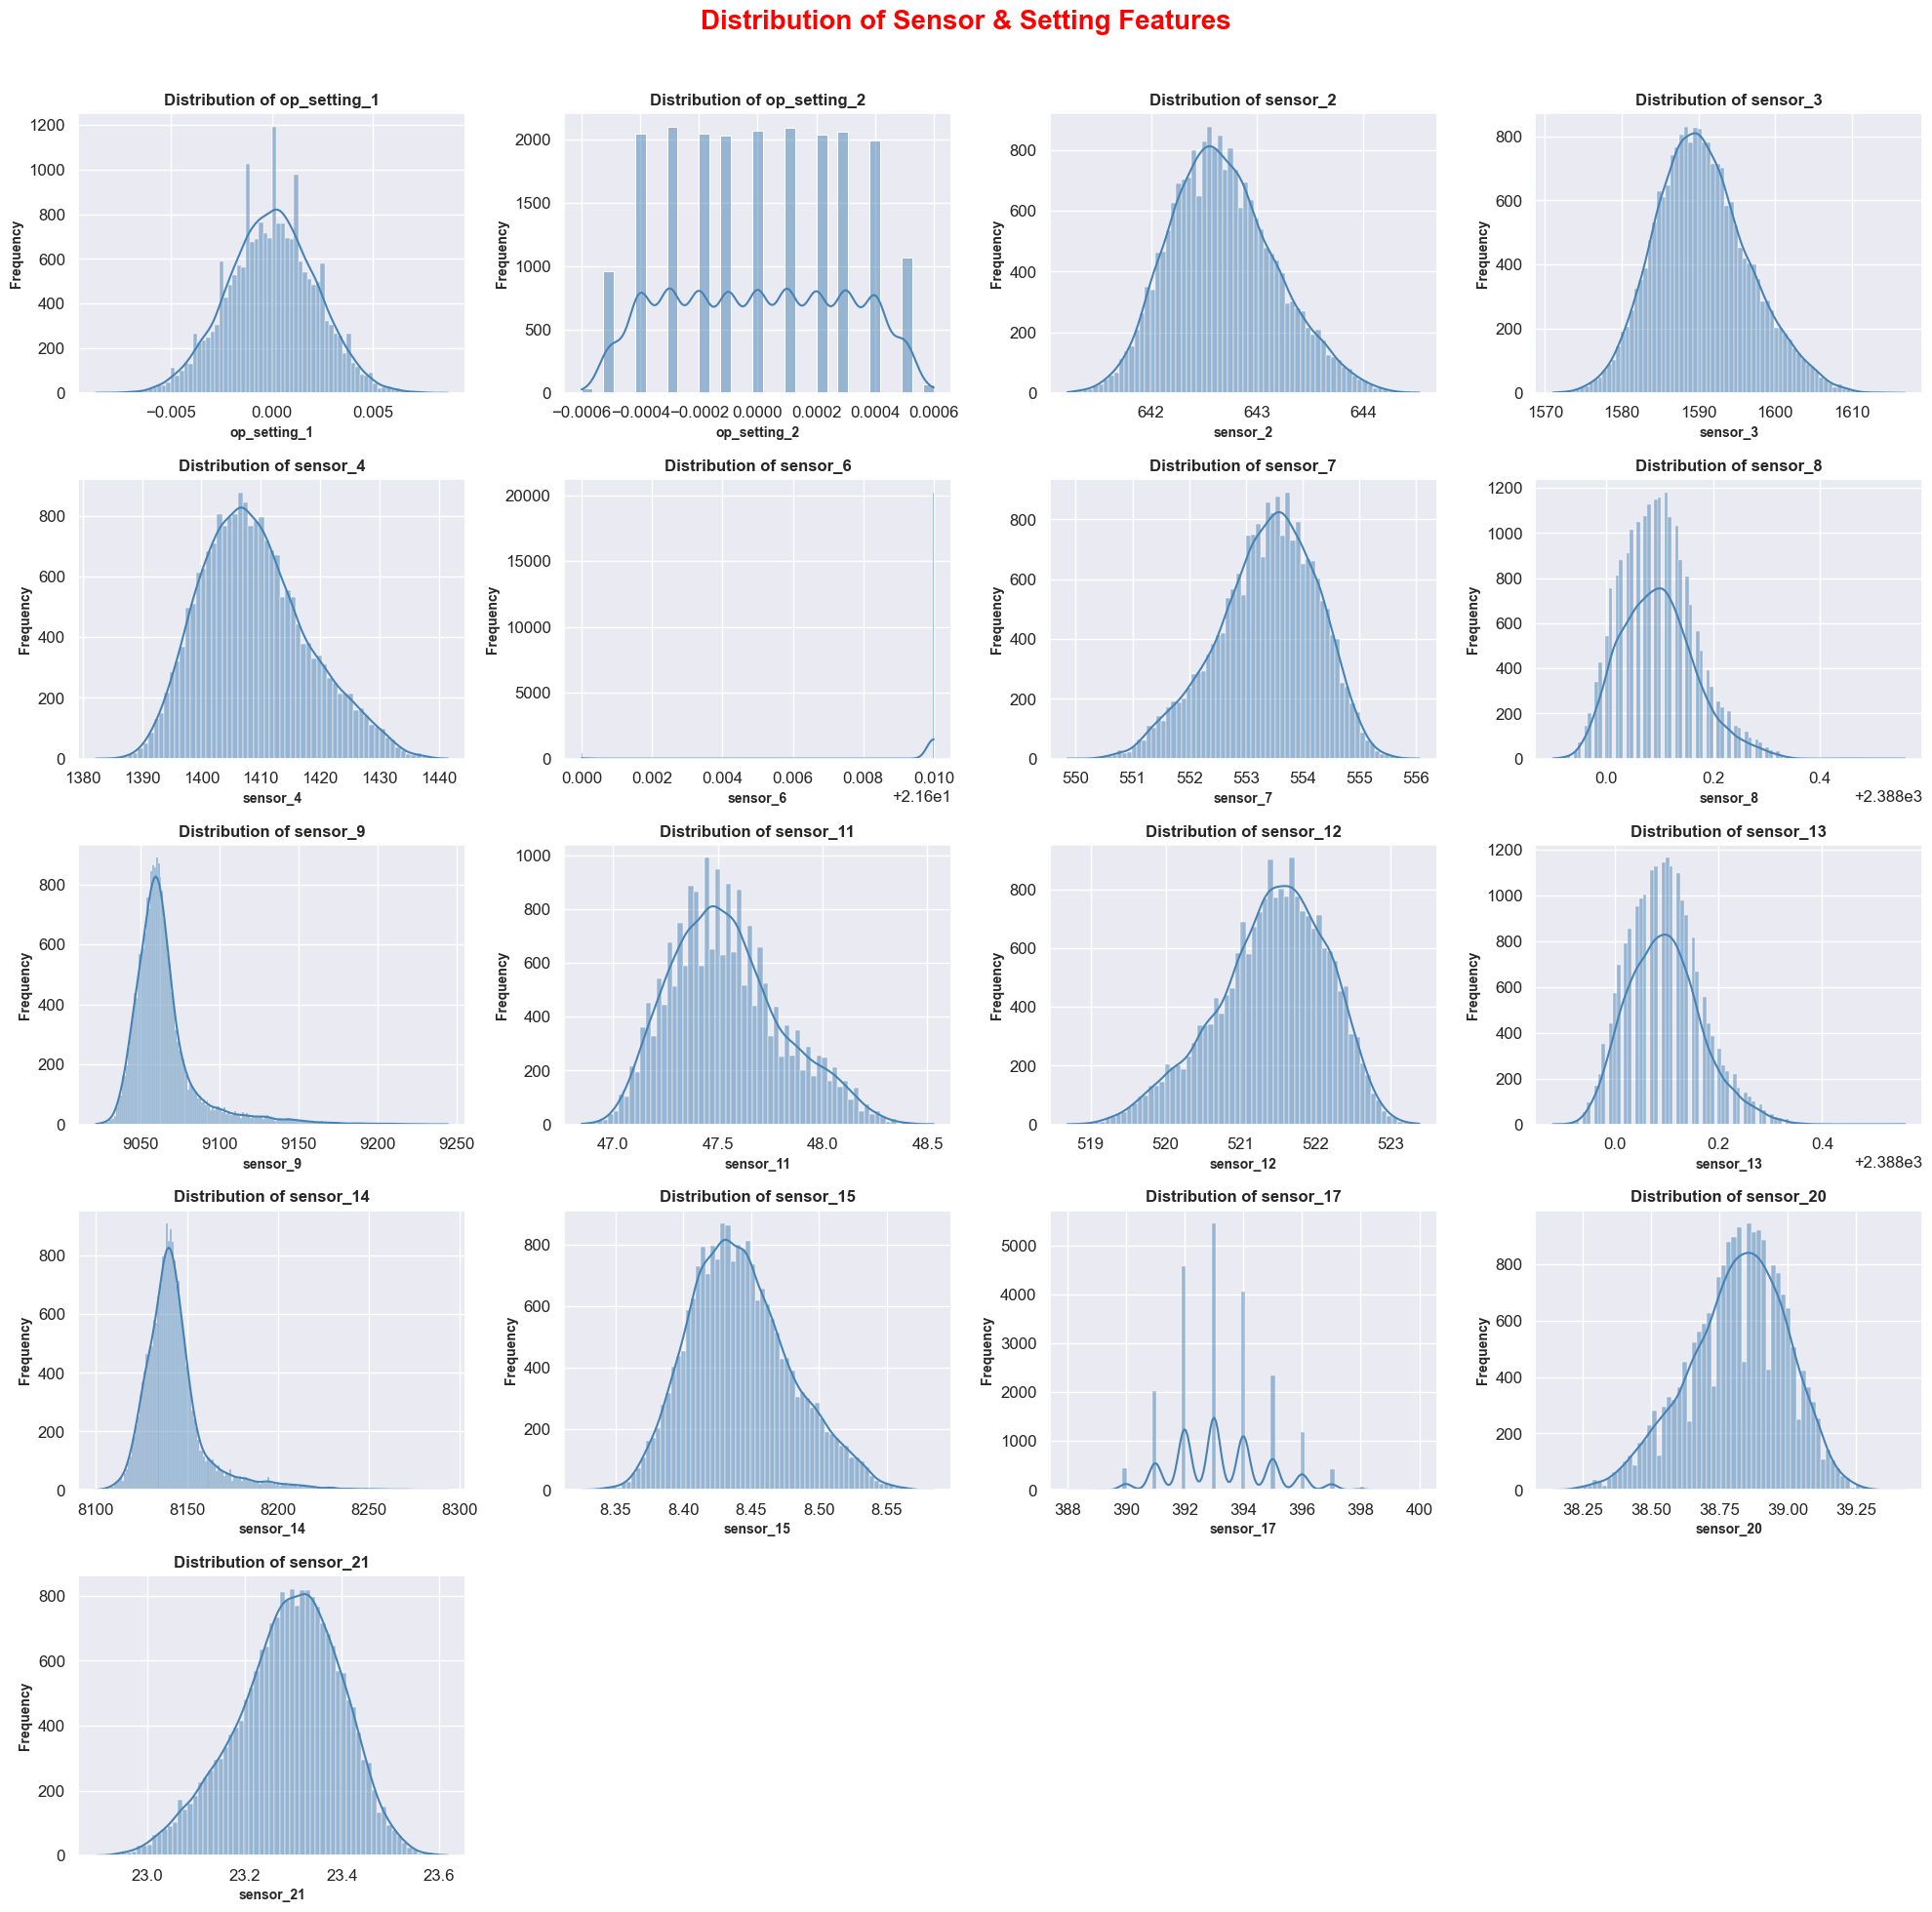

In [11]:
n = len(numerical_features)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(data=train, x=feature, ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(f"Distribution of {feature}", fontweight="bold", fontsize=12)
    axes[i].set_xlabel(feature, fontsize=10, fontweight="bold")
    axes[i].set_ylabel("Frequency", fontsize=10, fontweight="bold")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of Sensor & Setting Features", fontsize=20, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

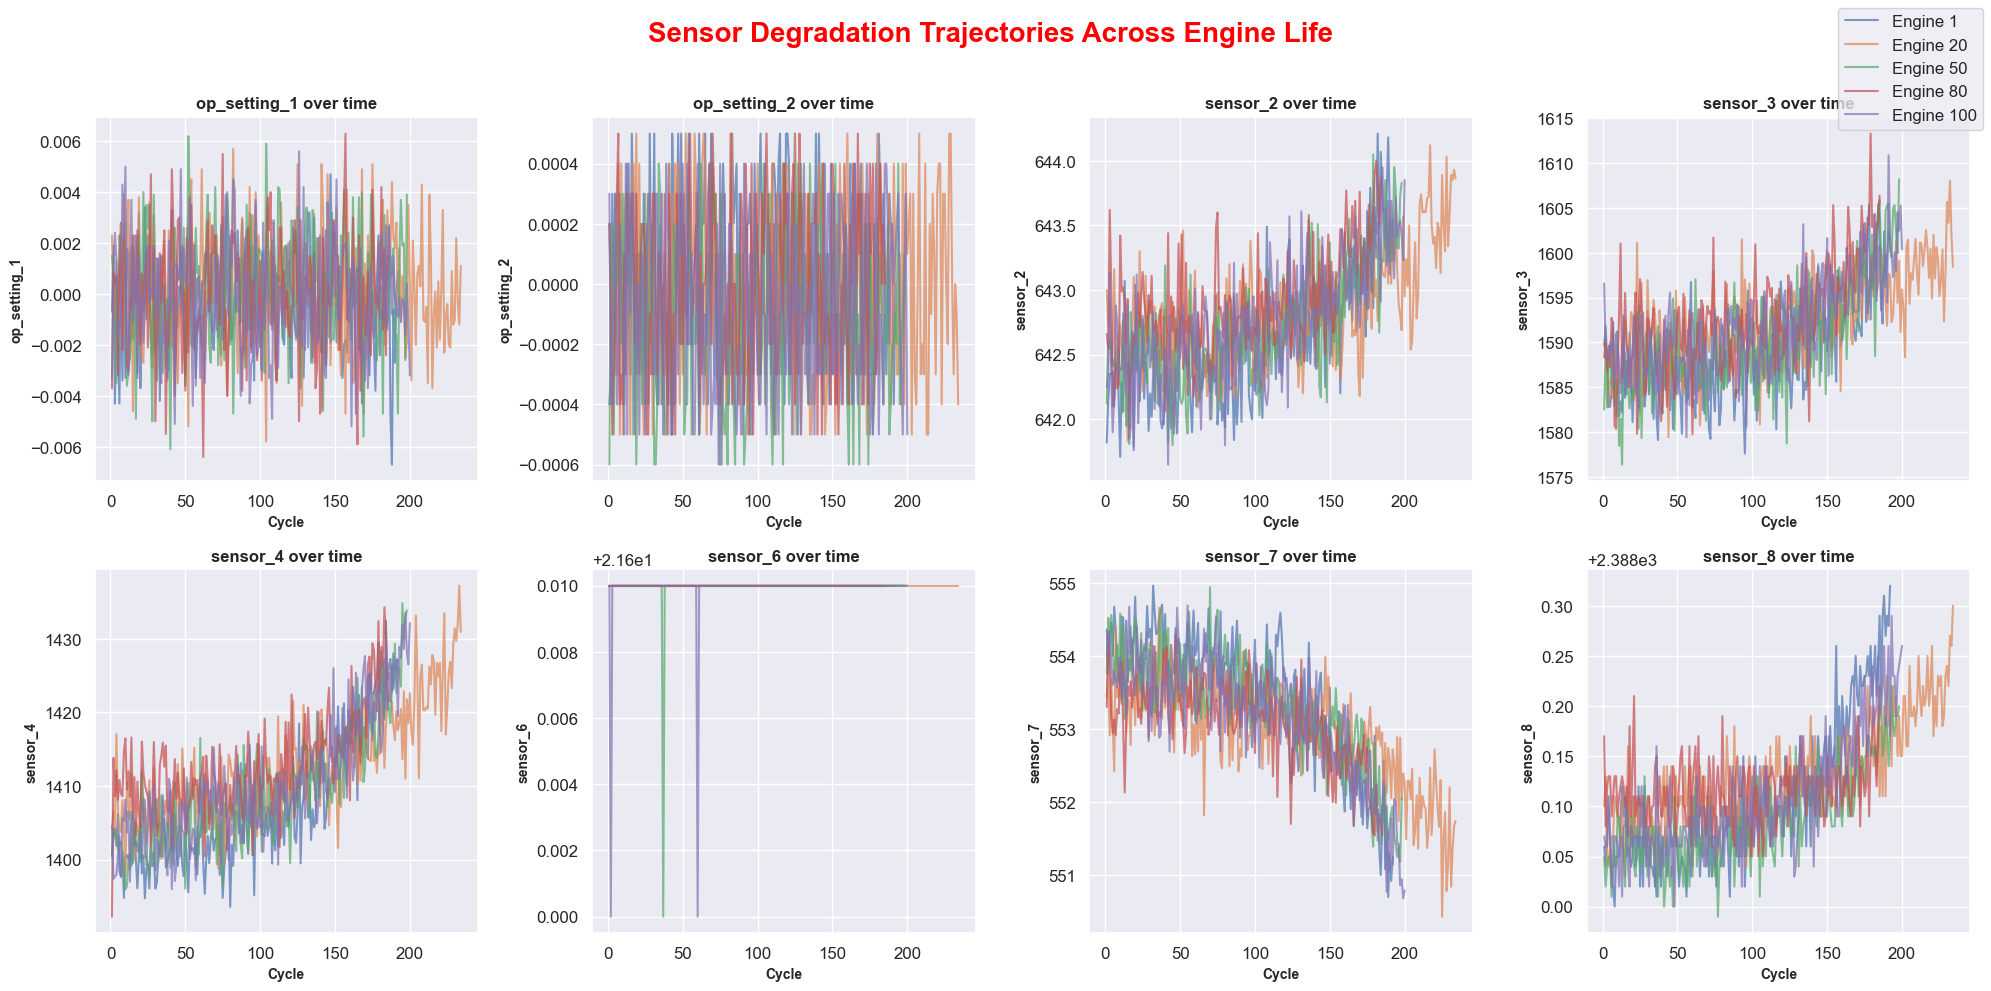

In [12]:
# C-MAPSS features are all continuous, so in place of categorical count plots we
# visualise how a sample of sensors degrade over an engine's operating life.
sample_units = [1, 20, 50, 80, 100]
sample_sensors = numerical_features[:8]

ncols = 4
nrows = math.ceil(len(sample_sensors) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

for i, sensor in enumerate(sample_sensors):
    for u in sample_units:
        eng = train[train['unit'] == u]
        axes[i].plot(eng['cycle'], eng[sensor], alpha=0.7, label=f"Engine {u}")
    axes[i].set_title(f"{sensor} over time", fontweight="bold", fontsize=12)
    axes[i].set_xlabel("Cycle", fontsize=10, fontweight="bold")
    axes[i].set_ylabel(sensor, fontsize=10, fontweight="bold")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
plt.suptitle("Sensor Degradation Trajectories Across Engine Life", fontsize=20, fontweight="bold", color="red")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Target Analysis

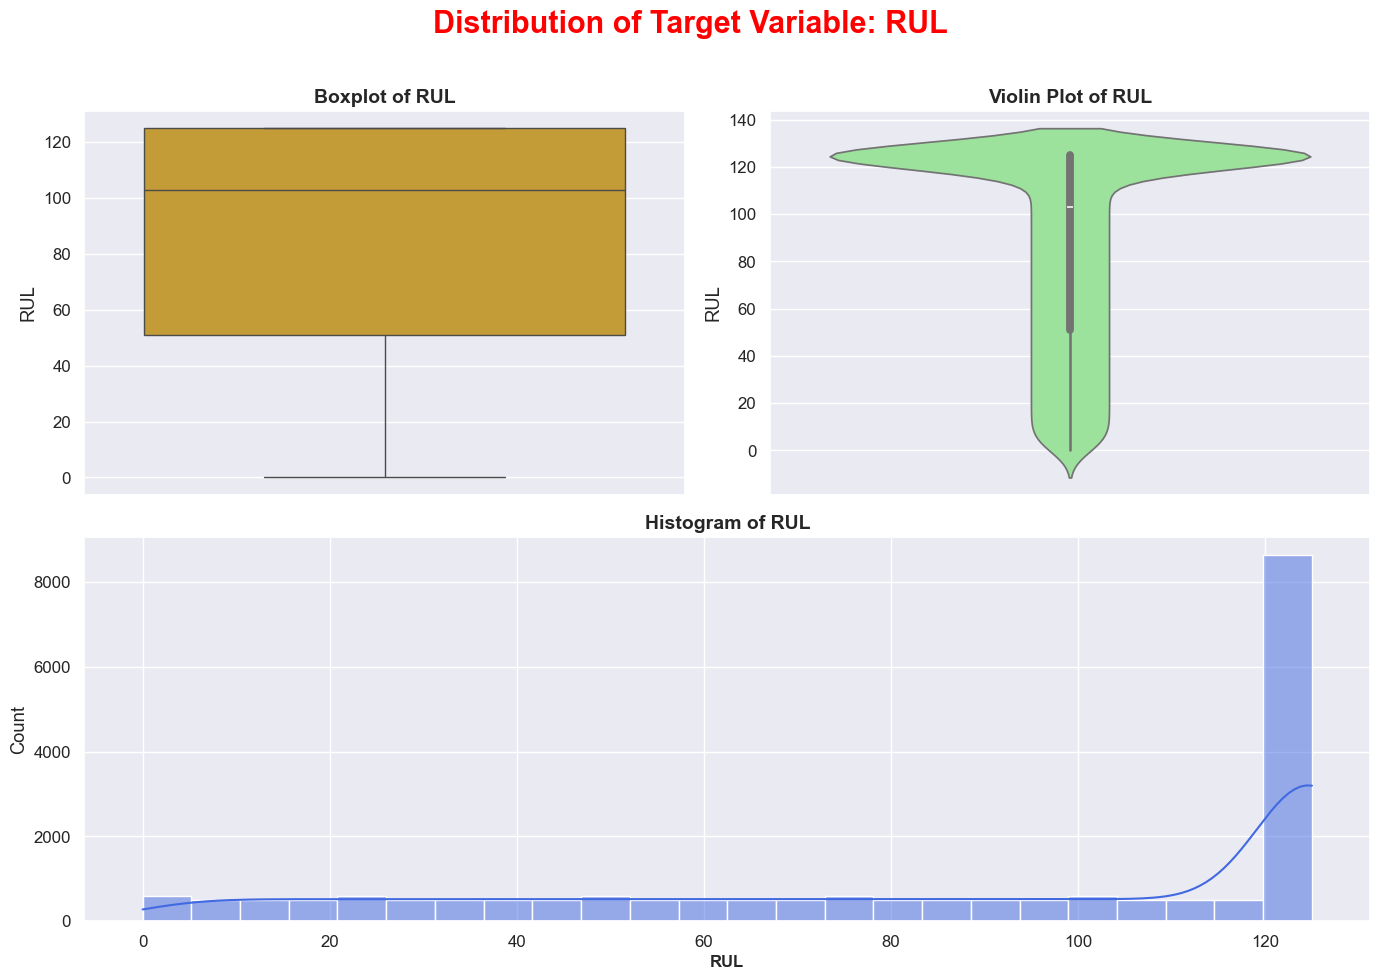

In [13]:
fig, axes = plt.subplot_mosaic([['A', 'B'], ['C', 'C']], figsize=(14, 10))
sns.boxplot(y=target, data=train, ax=axes['A'], color='goldenrod')
axes['A'].set_title(f"Boxplot of {target}", fontweight="bold", fontsize=14)

sns.violinplot(y=target, data=train, ax=axes['B'], color='lightgreen')
axes['B'].set_title(f"Violin Plot of {target}", fontweight="bold", fontsize=14)

sns.histplot(train[target], kde=True, ax=axes['C'], color='royalblue')
axes['C'].set_title(f"Histogram of {target}", fontweight="bold", fontsize=14)
axes['C'].set_xlabel(target, fontsize=12, fontweight="bold")

plt.suptitle(f"Distribution of Target Variable: {target}", fontsize=22, fontweight="bold", color='red')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Bivariate Analysis

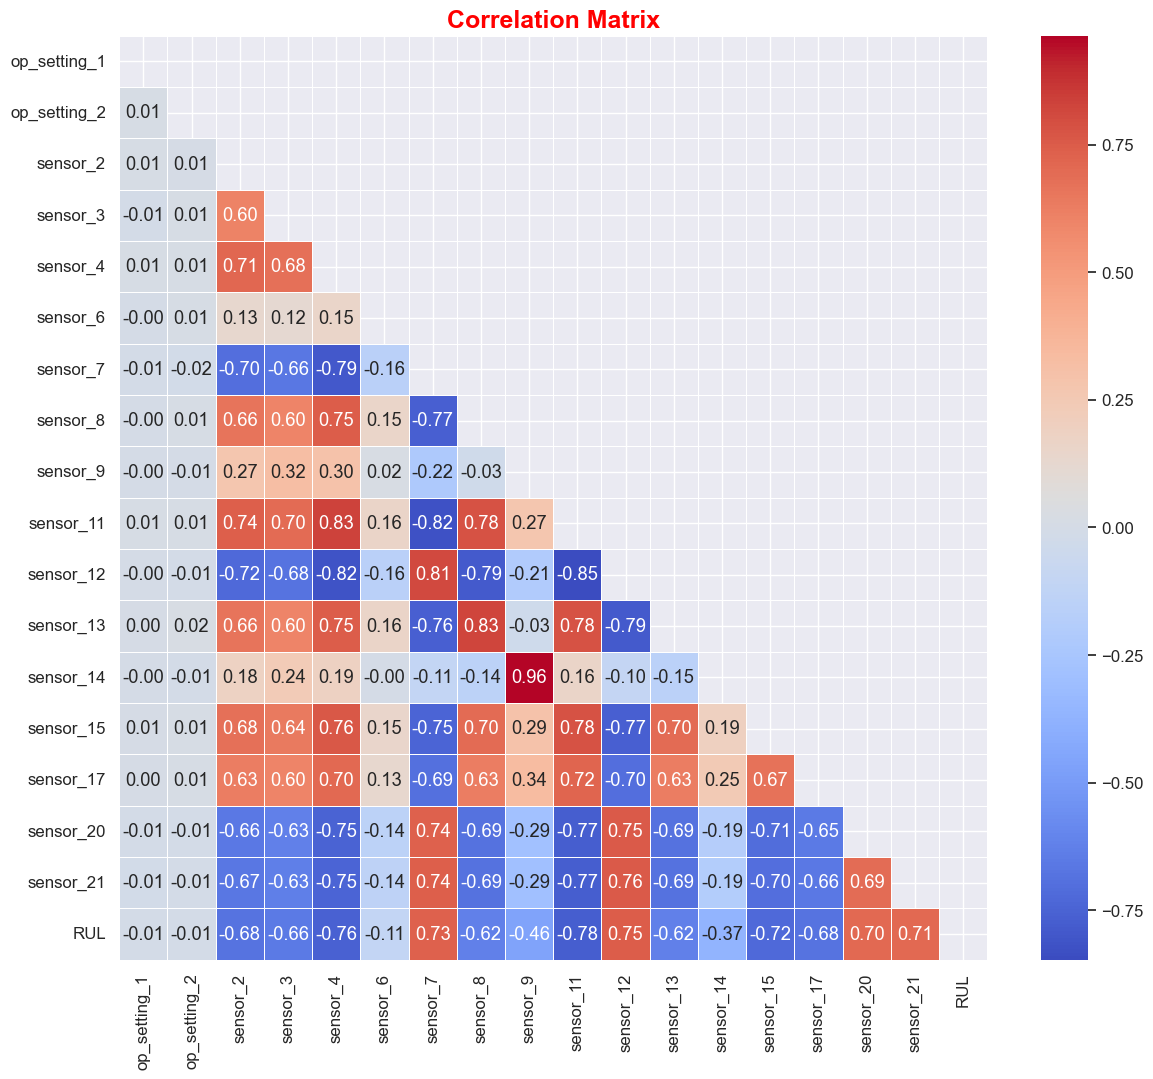

In [14]:
corr = train[numerical_features + [target]].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=18, fontweight="bold", color="red")
plt.show()

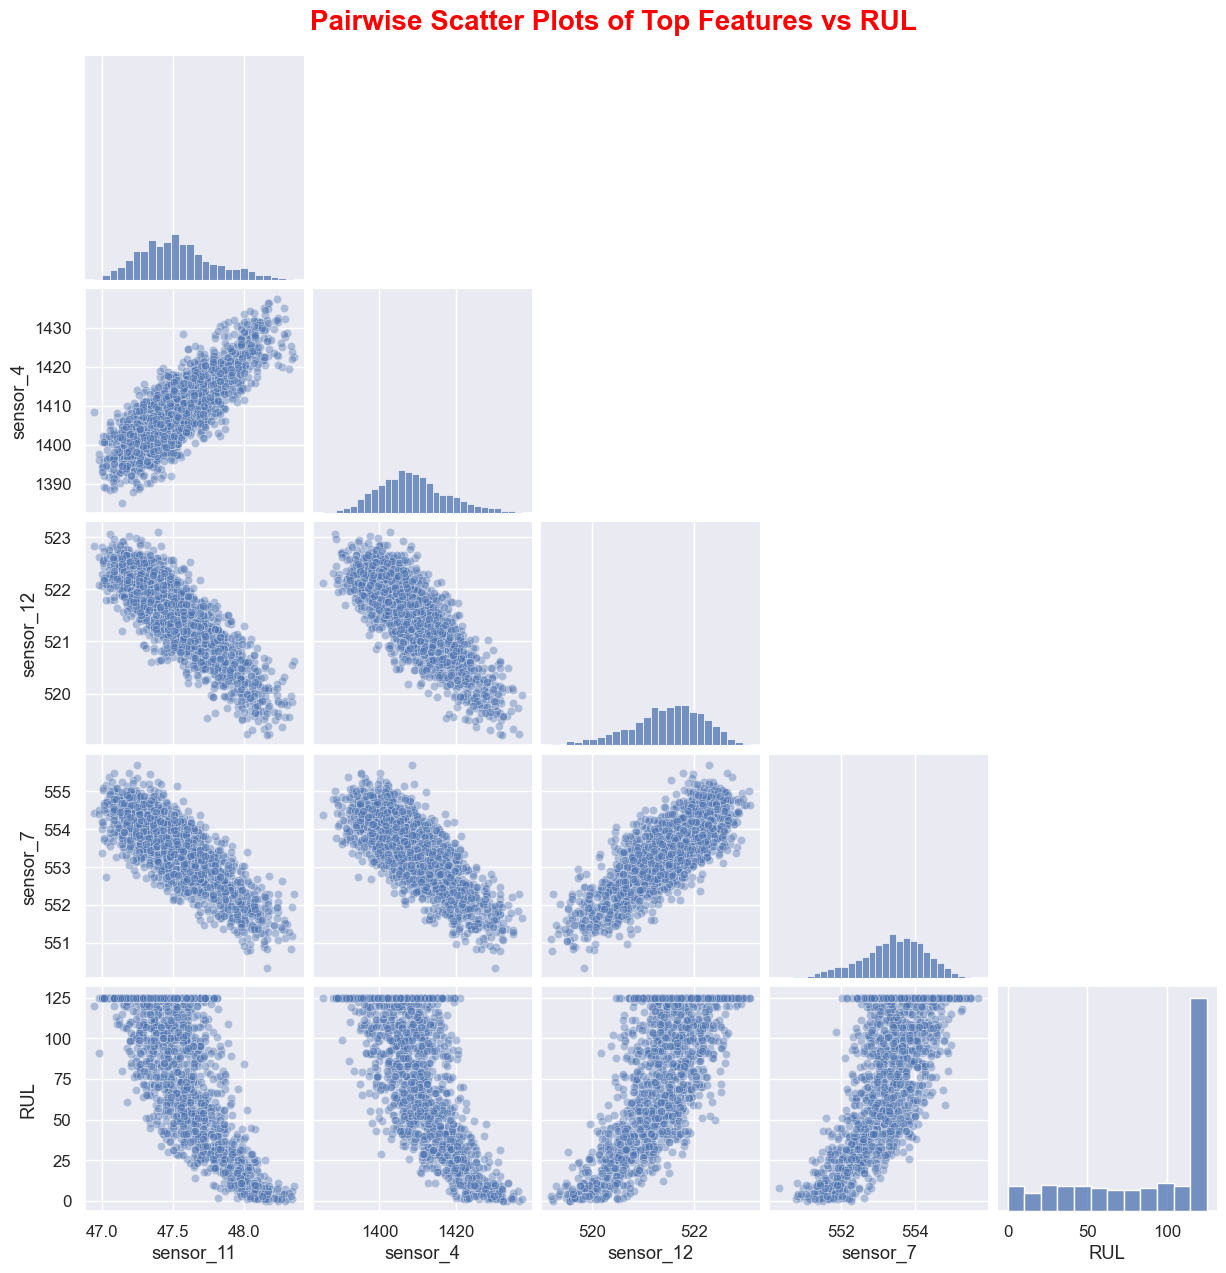

In [15]:
top_corr_features = corr[target].abs().sort_values(ascending=False)[1:5].index.tolist()

sample_df = train[top_corr_features + [target]].sample(n=min(2000, len(train)), random_state=42)
sns.pairplot(sample_df, vars=top_corr_features + [target], kind='scatter', corner=True, plot_kws={'alpha': 0.4})
plt.suptitle("Pairwise Scatter Plots of Top Features vs RUL",
             fontsize=20, fontweight="bold", color="red", y=1.02)
plt.show()

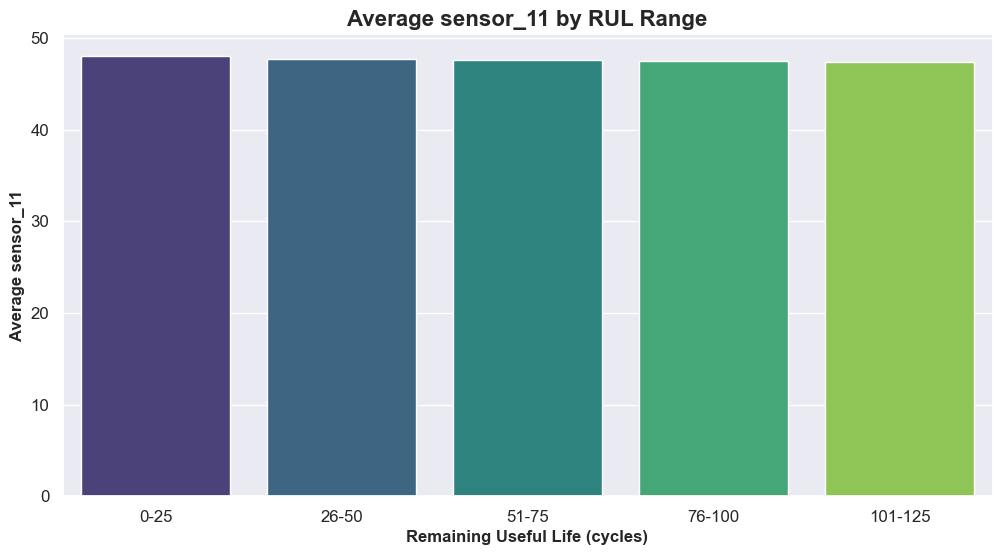

In [16]:
top_sensor = top_corr_features[0]
train['RUL_bin'] = pd.cut(train['RUL'], bins=[-1, 25, 50, 75, 100, 125],
                          labels=['0-25', '26-50', '51-75', '76-100', '101-125'])

plt.figure(figsize=(12, 6))
sns.barplot(x='RUL_bin', y=top_sensor, data=train, ci=None, palette='viridis')
plt.title(f"Average {top_sensor} by RUL Range", fontsize=16, fontweight='bold')
plt.xlabel("Remaining Useful Life (cycles)", fontsize=12, fontweight='bold')
plt.ylabel(f"Average {top_sensor}", fontsize=12, fontweight='bold')
plt.show()

train.drop(columns='RUL_bin', inplace=True)

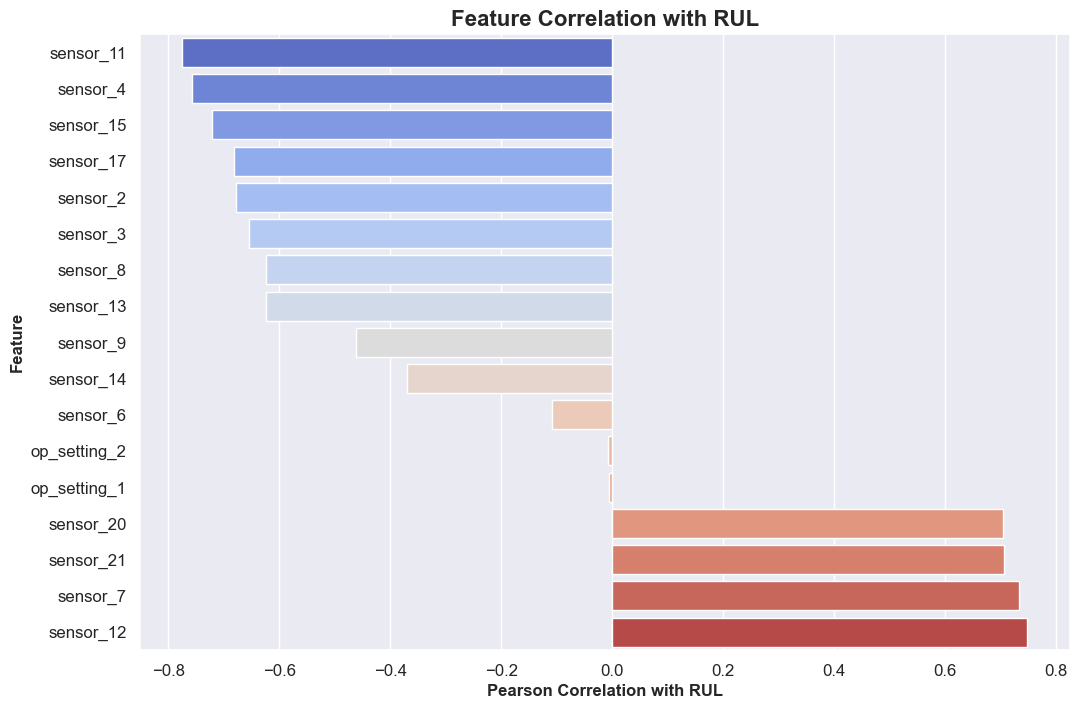

In [17]:
plt.figure(figsize=(12, 8))
feat_corr = corr[target].drop(target).sort_values()
sns.barplot(x=feat_corr.values, y=feat_corr.index, palette='coolwarm')
plt.title("Feature Correlation with RUL", fontsize=16, fontweight='bold')
plt.xlabel("Pearson Correlation with RUL", fontsize=12, fontweight='bold')
plt.ylabel("Feature", fontsize=12, fontweight='bold')
plt.show()

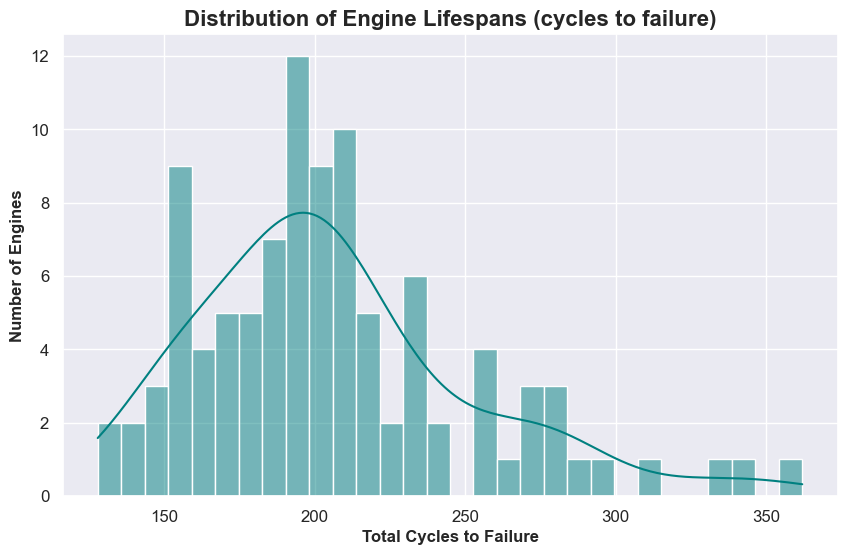

In [18]:
lifespans = train.groupby('unit')['cycle'].max()

plt.figure(figsize=(10, 6))
sns.histplot(lifespans, bins=30, kde=True, color='teal')
plt.title("Distribution of Engine Lifespans (cycles to failure)", fontsize=16, fontweight='bold')
plt.xlabel("Total Cycles to Failure", fontsize=12, fontweight='bold')
plt.ylabel("Number of Engines", fontsize=12, fontweight='bold')
plt.show()

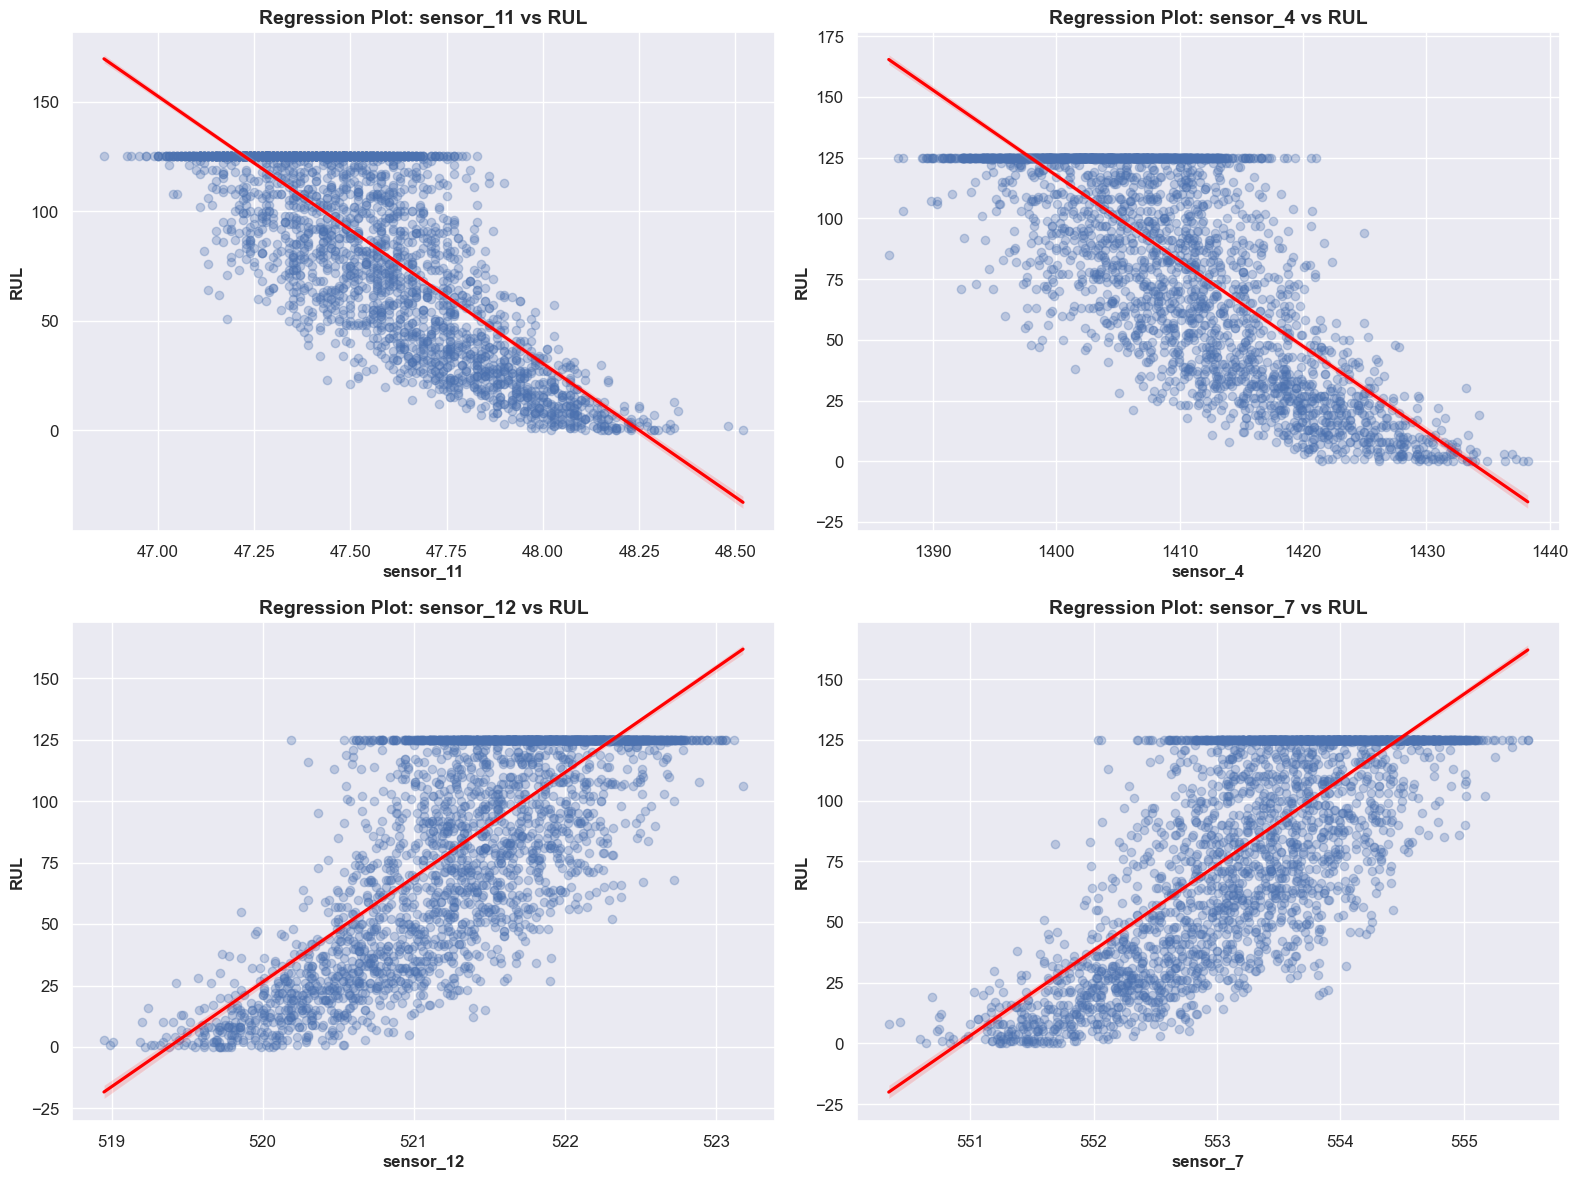

In [19]:
plot_df = train.sample(n=min(3000, len(train)), random_state=1)

plt.figure(figsize=(16, 12))
for i, feature in enumerate(top_corr_features, 1):
    plt.subplot(2, 2, i)
    sns.regplot(x=feature, y=target, data=plot_df,
                scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
    plt.title(f"Regression Plot: {feature} vs RUL", fontsize=14, fontweight='bold')
    plt.xlabel(feature, fontsize=12, fontweight='bold')
    plt.ylabel("RUL", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 🛠️ Feature Engineering & Preprocessing

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Before training, we prepare the dataset so the models receive clean, well-scaled inputs.
    For C-MAPSS this means removing flat sensors, scaling the remaining numerical channels, and (optionally) transforming the target to stabilise training.
</div>

## 🔧 Key Preprocessing Steps

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li><strong>Constant-channel removal:</strong> Drop sensors that never change (no signal) &mdash; handled in the EDA step above.</li>
        <li><strong>Scaling Numerical Features:</strong> Apply <code>MinMaxScaler</code> so every sensor lives on a comparable [0, 1] range, which helps gradient-based models converge.</li>
        <li><strong>Target Clipping:</strong> RUL is clipped at 125 cycles so the model focuses on the degradation regime rather than the flat, healthy early life.</li>
        <li><strong>Target Transformation:</strong> A <code>log1p</code> transform is applied to RUL during training (and inverted for scoring) to reduce the influence of large values and stabilise the loss.</li>
        <li><strong>Categorical Encoding:</strong> Included in the pipeline for completeness via <code>OneHotEncoder</code>; C-MAPSS FD001 has no categorical columns, so this is a no-op here.</li>
    </ul>
</div>

# 🏗️ Model Building

<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    In this section we train regression models to predict <strong>RUL</strong> from the preprocessed sensor features.
    Our goal is to accurately estimate how many cycles remain before each engine fails.
</div>

## 🔭 Choice of Models

<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Gradient-boosted trees are the strongest off-the-shelf models for tabular sensor data, so we train a diverse ensemble:
    <ul>
        <li><strong>XGBoost / LightGBM / CatBoost:</strong> High-performance boosting libraries that capture complex non-linear sensor interactions.</li>
        <li><strong>HistGradientBoostingRegressor:</strong> A fast scikit-learn boosting baseline.</li>
        <li><strong>Random Forest (XGBRF):</strong> A robust bagging baseline for comparison.</li>
        <li><strong>Ridge meta-learner:</strong> Stacks the out-of-fold predictions of the base models into a single, stronger estimate.</li>
    </ul>
    Every model is trained with K-Fold cross-validation and scored with RMSE (in cycles) and R&sup2;.
</div>

In [20]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

from sklearn.ensemble import RandomForestRegressor

# root_mean_squared_error was added in scikit-learn 1.4; fall back for older versions.
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

# root_mean_squared_error was added in scikit-learn 1.4; fall back for older versions.
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

import lightgbm as lgb

def model_trainer(model, X, y, test=None, nsplits=5, random_state=42, log_target=False, verbose=0, model_name=None):

    kfold = KFold(n_splits=nsplits, shuffle=True, random_state=random_state)

    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()
    y_array = y.to_numpy() if isinstance(y, pd.Series) else y.copy()

    if log_target:
        y_array = np.log1p(y_array)

    oof_train_preds = np.zeros(len(y_array))
    if test is not None:
        if isinstance(test, pd.DataFrame):
            test = test.to_numpy()
        oof_test_preds = np.zeros(len(test))

    oof_rmse = []
    oof_r2 = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X), 1):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y_array[train_idx], y_array[val_idx]

        if model_name == 'xgb':
            model.fit(X_train, y_train,
                      eval_set=[(X_val, y_val)],
                      verbose=verbose)
            if hasattr(model, 'best_iteration') and model.best_iteration is not None:
                y_pred = model.predict(X_val, iteration_range=(0, model.best_iteration + 1))
            else:
                y_pred = model.predict(X_val)

        elif model_name == 'lgb':
            model.fit(X_train, y_train,
                      eval_set=[(X_val, y_val)],
                      callbacks=[lgb.early_stopping(200, verbose=verbose)])
            y_pred = model.predict(X_val)

        elif model_name == 'cat':
            model.fit(X_train, y_train,
                      eval_set=[(X_val, y_val)],
                      early_stopping_rounds=200,
                      verbose=verbose)
            y_pred = model.predict(X_val)

        elif model_name == 'hgb':
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

        if log_target:
            y_val_exp = np.expm1(y_val)
            y_pred_exp = np.expm1(y_pred)
        else:
            y_val_exp = y_val
            y_pred_exp = y_pred

        rmse = root_mean_squared_error(y_val_exp, y_pred_exp)
        r2 = r2_score(y_val_exp, y_pred_exp)
        oof_rmse.append(rmse)
        oof_r2.append(r2)

        oof_train_preds[val_idx] = y_pred

        if test is not None:
            test_pred = None
            if model_name == 'xgb':
                if hasattr(model, 'best_iteration') and model.best_iteration is not None:
                    test_pred = model.predict(test, iteration_range=(0, model.best_iteration + 1))
                else:
                    test_pred = model.predict(test)
            else:
                test_pred = model.predict(test)

            if log_target:
                test_pred = np.expm1(test_pred)

            oof_test_preds += test_pred / nsplits

        print(f"Fold {fold} -> RMSE: {rmse:.4f}, R2: {r2:.4f}")

    print(f"\nAverage Fold RMSE Score: {np.mean(oof_rmse):.4f} +/- {np.std(oof_rmse):.4f}")
    print(f"Average Fold R2 Score: {np.mean(oof_r2):.4f} +/- {np.std(oof_r2):.4f}")

    if test is not None:
        return oof_train_preds, oof_test_preds

    return oof_train_preds

In [22]:
numeric_transformer = MinMaxScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

transformers = [('num', numeric_transformer, numerical_features)]
if categorical_features:
    transformers.append(('cat', categorical_transformer, categorical_features))

preprocessor = ColumnTransformer(transformers=transformers)

In [23]:
X = train[features].copy()
y = train[target].copy()
# RUL is log-transformed inside model_trainer (log_target=True) and inverted for
# scoring, so RMSE is reported back in real cycles.

In [24]:
comb = pd.concat([X, test_last[features]], axis=0)

preprocessor.fit(comb)

X_processed = preprocessor.transform(X)
test_processed = preprocessor.transform(test_last[features])

In [25]:
oof_train_preds = pd.DataFrame()
oof_test_preds = pd.DataFrame()

In [26]:
from xgboost import XGBRFRegressor
rf = XGBRFRegressor(n_estimators=200, tree_method='hist')
_ = model_trainer(rf, X_processed, y, log_target=True)

Fold 1 -> RMSE: 20.0054, R2: 0.7641


Fold 2 -> RMSE: 19.8701, R2: 0.7731


Fold 3 -> RMSE: 19.5616, R2: 0.7770


Fold 4 -> RMSE: 19.0012, R2: 0.7937


Fold 5 -> RMSE: 19.5500, R2: 0.7850

Average Fold RMSE Score: 19.5977 +/- 0.3463
Average Fold R2 Score: 0.7786 +/- 0.0101


In [27]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    early_stopping_rounds=100,
    n_estimators=2000,
    eta=0.02,
    max_depth=6,
    colsample_bytree=0.7,
    subsample=0.9,
    seed=42
)
oof_train_preds['xgb'], oof_test_preds['xgb'] = model_trainer(xgb_reg, X_processed, y, test_processed,
                                                              nsplits=5, log_target=True, model_name='xgb', verbose=0)

Fold 1 -> RMSE: 18.7939, R2: 0.7918


Fold 2 -> RMSE: 18.1961, R2: 0.8098


Fold 3 -> RMSE: 18.1037, R2: 0.8090


Fold 4 -> RMSE: 17.7240, R2: 0.8205


Fold 5 -> RMSE: 18.3388, R2: 0.8108

Average Fold RMSE Score: 18.2313 +/- 0.3473
Average Fold R2 Score: 0.8084 +/- 0.0093


In [28]:
from catboost import CatBoostRegressor

cat_reg = CatBoostRegressor(
    loss_function="RMSE",
    n_estimators=3000,
    learning_rate=0.02,
    depth=8,
    random_seed=42,
    allow_writing_files=False
)

oof_train_preds['cat'], oof_test_preds['cat'] = model_trainer(cat_reg, X_processed, y, test_processed, nsplits=5,
                                                              log_target=True, verbose=0, model_name='cat')

Fold 1 -> RMSE: 18.6385, R2: 0.7952


Fold 2 -> RMSE: 18.1252, R2: 0.8112


Fold 3 -> RMSE: 18.0407, R2: 0.8103


Fold 4 -> RMSE: 17.7207, R2: 0.8206


Fold 5 -> RMSE: 18.3139, R2: 0.8113

Average Fold RMSE Score: 18.1678 +/- 0.3035
Average Fold R2 Score: 0.8097 +/- 0.0082


In [29]:
from lightgbm import LGBMRegressor

lgb_reg = LGBMRegressor(
    objective="regression",
    metric="rmse",
    n_estimators=3000,
    learning_rate=0.02,
    max_depth=8,
    random_state=42,
    verbosity=-1
)

oof_train_preds['lgb'], oof_test_preds['lgb'] = model_trainer(lgb_reg, X_processed, y, test_processed, log_target=True,
                                                              nsplits=5,
                                                              model_name='lgb', verbose=False)

Fold 1 -> RMSE: 18.8670, R2: 0.7902


Fold 2 -> RMSE: 18.3289, R2: 0.8070


Fold 3 -> RMSE: 18.1241, R2: 0.8086


Fold 4 -> RMSE: 17.7550, R2: 0.8199


Fold 5 -> RMSE: 18.4132, R2: 0.8093

Average Fold RMSE Score: 18.2976 +/- 0.3642
Average Fold R2 Score: 0.8070 +/- 0.0096


In [30]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(max_iter=2000, learning_rate=0.02, early_stopping=True, n_iter_no_change=100)
oof_train_preds['hgb'], oof_test_preds['hgb'] = model_trainer(hgb, X_processed, y, test_processed, log_target=True, nsplits=5, model_name='hgb')

Fold 1 -> RMSE: 18.9410, R2: 0.7885


Fold 2 -> RMSE: 18.2767, R2: 0.8081


Fold 3 -> RMSE: 18.1223, R2: 0.8086


Fold 4 -> RMSE: 17.7975, R2: 0.8190


Fold 5 -> RMSE: 18.5104, R2: 0.8073

Average Fold RMSE Score: 18.3296 +/- 0.3835
Average Fold R2 Score: 0.8063 +/- 0.0099


## Meta Learner

In [31]:
from sklearn.linear_model import Ridge

lr = Ridge(positive=True)

_, test_preds = model_trainer(lr, oof_train_preds, y, oof_test_preds, nsplits=5, log_target=True, random_state=101)

Fold 1 -> RMSE: 18.3067, R2: 0.8014
Fold 2 -> RMSE: 18.0906, R2: 0.8109
Fold 3 -> RMSE: 18.0039, R2: 0.8164
Fold 4 -> RMSE: 18.0608, R2: 0.8131
Fold 5 -> RMSE: 18.3312, R2: 0.8085

Average Fold RMSE Score: 18.1586 +/- 0.1341
Average Fold R2 Score: 0.8100 +/- 0.0051


# Submission

In [32]:
# Predicted RUL at each engine's last observed cycle.
test_preds = np.clip(test_preds, 0, RUL_CLIP)

sub = pd.DataFrame({'unit': test_last['unit'].values, 'RUL': test_preds})
sub.to_csv("submission.csv", index=False)

# Benchmark against the ground-truth RUL provided by NASA (RUL_FD001.txt).
final_rmse = root_mean_squared_error(rul_truth['RUL'].values, test_preds)
final_r2 = r2_score(rul_truth['RUL'].values, test_preds)
print(f"Final Test RMSE: {final_rmse:.4f} cycles")
print(f"Final Test R2  : {final_r2:.4f}")

sub.head()

Final Test RMSE: 64.6153 cycles
Final Test R2  : -1.4178


,unit,RUL
0,1,125.0
1,2,125.0
2,3,125.0
3,4,125.0
4,5,125.0


<center>
    <img src="https://media.giphy.com/media/Gz6nYcm8oXE4dFTC8j/giphy.gif" height="150" width="300">
</center>

<h2 style="color: red; text-align: center;">Thank you for reading &mdash; happy predicting! 🚀</h2>